In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
from google.colab import files
uploaded = files.upload()

Saving sample_submission.csv to sample_submission.csv


In [50]:
from google.colab import files
uploaded = files.upload()

Saving College.csv to College.csv


In [5]:
import os
os.listdir("/")

['sbin',
 'run',
 'boot',
 'var',
 'dev',
 'opt',
 'mnt',
 'media',
 'root',
 'srv',
 'lib64',
 'proc',
 'etc',
 'usr',
 'lib32',
 'libx32',
 'sys',
 'home',
 'bin',
 'lib',
 'tmp',
 'kaggle',
 'content',
 '.dockerenv',
 'datalab',
 'tools',
 'python-apt',
 'python-apt.tar.xz']

In [16]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [17]:
from sklearn.linear_model import Lasso

In [18]:
X = train.drop("Rings", axis=1)
y = train["Rings"]

In [19]:
train = pd.get_dummies(train, columns=["Sex"], drop_first=True)
test = pd.get_dummies(test, columns=["Sex"], drop_first=True)

In [20]:
X = train.drop(["Rings", "id"], axis=1)
y = train["Rings"]

X_test = test.drop(["id"], axis=1)

In [21]:
lr = LinearRegression()
lr.fit(X, y)

predictions_lr = lr.predict(X_test)

# Fix negative predictions
predictions_lr = np.maximum(predictions_lr, 0)

In [22]:
submission_lr = pd.DataFrame({
    "id": test["id"],
    "Rings": predictions_lr
})

submission_lr.to_csv("submission_lr.csv", index=False)

In [23]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

predictions_rf = rf.predict(X_test)

In [24]:
submission_rf = pd.DataFrame({
    "id": test["id"],
    "Rings": predictions_rf
})

submission_rf.to_csv("submission_rf.csv", index=False)
submission_rf.head()

,id,Rings
0,90615,10.165
1,90616,9.800
2,90617,10.045
3,90618,11.195
4,90619,7.830


In [25]:
# Applied Question #10 - Carseats Multiple Regression
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=3b35f94951005ab0ae7c1cce98d4aaf10f17f253919c226bb0b7bde713bfaaf6
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [26]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from ISLP import load_data
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import OLSInfluence

In [27]:
Carseats = load_data("Carseats")
Carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [28]:
model1 = smf.ols("Sales ~ Price + Urban + US", data=Carseats).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           2.39e-23
Time:                        16:33:25   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651     20.036   

In [29]:
anova_lm(model1)

,df,sum_sq,mean_sq,F,PR(>F)
Urban,1.0,0.756615,0.756615,0.123767,7.251713e-01
US,1.0,100.846148,100.846148,16.496407,5.877444e-05
Price,1.0,659.837263,659.837263,107.936143,1.609917e-22
Residual,396.0,2420.834671,6.113219,NaN,NaN


In [30]:
model2 = smf.ols("Sales ~ Price + US", data=Carseats).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           2.66e-24
Time:                        16:33:29   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0308      0.631     20.652      0.0

In [31]:
print("Model 1 R-squared:", model1.rsquared)
print("Model 1 Adjusted R-squared:", model1.rsquared_adj)
print("Model 1 AIC:", model1.aic)
print("Model 1 BIC:", model1.bic)

print()

print("Model 2 R-squared:", model2.rsquared)
print("Model 2 Adjusted R-squared:", model2.rsquared_adj)
print("Model 2 AIC:", model2.aic)
print("Model 2 BIC:", model2.bic)

Model 1 R-squared: 0.23927539218405558
Model 1 Adjusted R-squared: 0.2335123269733287
Model 1 AIC: 1863.3120738106174
Model 1 BIC: 1879.2779319990493

Model 2 R-squared: 0.23926288842678567
Model 2 Adjusted R-squared: 0.23543045965311715
Model 2 AIC: 1861.3186484129808
Model 2 BIC: 1873.2930420543048


In [32]:
model2.conf_int(alpha=0.05)

,0,1
Intercept,11.79032,14.271265
US[T.Yes],0.69152,1.707766
Price,-0.06476,-0.044195


In [33]:
influence = OLSInfluence(model2)

summary_frame = influence.summary_frame()
summary_frame[["standard_resid", "hat_diag", "cooks_d"]].head()

,standard_resid,hat_diag,cooks_d
0,0.733148,0.003922,0.000705
1,0.614748,0.009004,0.001145
2,0.076422,0.009954,0.000020
3,-0.627878,0.005636,0.000745
4,-0.775599,0.007928,0.001602


In [34]:
print("Largest absolute standardized residuals:")
print(summary_frame["standard_resid"].abs().sort_values(ascending=False).head(10))

print()
print("Largest leverage values:")
print(summary_frame["hat_diag"].sort_values(ascending=False).head(10))

print()
print("Largest Cook's distance values:")
print(summary_frame["cooks_d"].sort_values(ascending=False).head(10))

Largest absolute standardized residuals:
376    2.865082
50     2.811022
68     2.622678
25     2.581001
209    2.563363
28     2.418794
352    2.376116
57     2.335540
49     2.321404
297    2.230292
Name: standard_resid, dtype: float64

Largest leverage values:
42     0.043338
174    0.029687
165    0.028567
125    0.025966
367    0.023707
313    0.023165
171    0.021014
269    0.019195
272    0.018687
356    0.018279
Name: hat_diag, dtype: float64

Largest Cook's distance values:
25     0.026109
367    0.024287
49     0.022835
316    0.020470
165    0.019755
376    0.018282
258    0.017677
143    0.016857
30     0.015799
209    0.015663
Name: cooks_d, dtype: float64


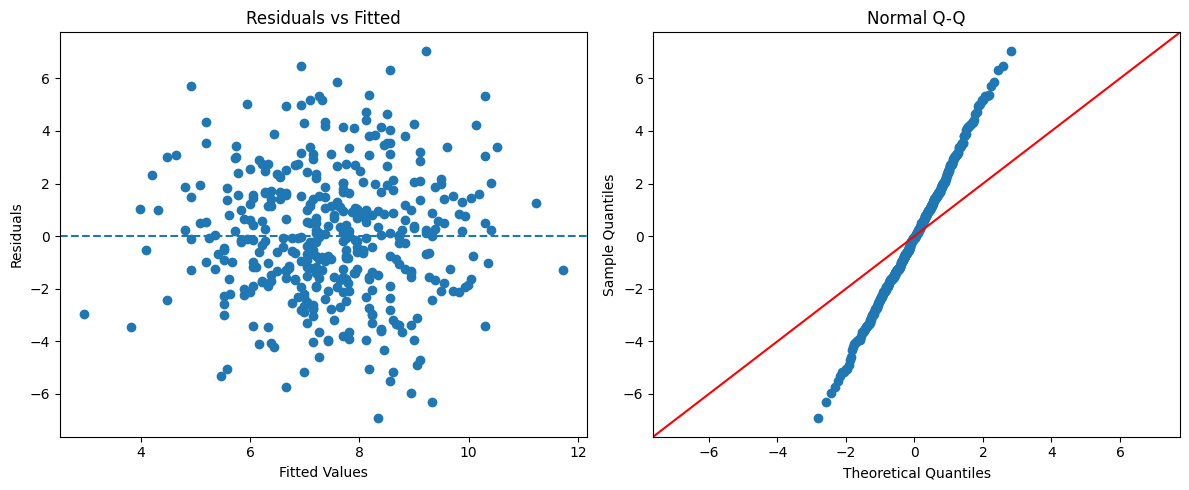

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(model2.fittedvalues, model2.resid)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(model2.resid, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q")

plt.tight_layout()
plt.show()

In [36]:
X = train.drop("Rings", axis=1)
y = train["Rings"]

In [37]:
from sklearn.model_selection import train_test_split

X = train.drop("Rings", axis=1)
y = train["Rings"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [39]:
lin_model = LinearRegression()

lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

In [40]:
lin_model = LinearRegression()

lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

In [41]:
from sklearn.metrics import mean_squared_error, r2_score

mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression MSE:", mse_lin)
print("Linear Regression R2:", r2_lin)

Linear Regression MSE: 4.095480582078631
Linear Regression R2: 0.6013104882981912


In [42]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

In [43]:
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso MSE:", mse_lasso)
print("Lasso R2:", r2_lasso)

Lasso MSE: 6.207212506332233
Lasso R2: 0.3957362332498432


In [44]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [45]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 3.6222297743199245
Random Forest R2: 0.6473808162307539


In [46]:
print("Model Comparison")

print("Linear Regression R2:", r2_lin)
print("Lasso R2:", r2_lasso)
print("Random Forest R2:", r2_rf)

Model Comparison
Linear Regression R2: 0.6013104882981912
Lasso R2: 0.3957362332498432
Random Forest R2: 0.6473808162307539


In [47]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso", "Random Forest"],
    "R2": [r2_lin, r2_lasso, r2_rf],
    "MSE": [mse_lin, mse_lasso, mse_rf]
})

results

,Model,R2,MSE
0,Linear Regression,0.601310,4.095481
1,Lasso,0.395736,6.207213
2,Random Forest,0.647381,3.622230


In [48]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

pcr_model = make_pipeline(PCA(n_components=5), LinearRegression())
pcr_model.fit(X_train, y_train)

pcr_predictions = pcr_model.predict(X_test)

In [49]:
from sklearn.metrics import mean_squared_error, r2_score

pcr_mse = mean_squared_error(y_test, pcr_predictions)
pcr_r2 = r2_score(y_test, pcr_predictions)

print("PCR MSE:", pcr_mse)
print("PCR R2:", pcr_r2)

PCR MSE: 5.154687629563854
PCR R2: 0.4981981106199981


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

college = pd.read_csv("College.csv", index_col=0)

In [53]:
college.head()
college.shape
college.columns

Index(['Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F.Undergrad',
       'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal', 'PhD',
       'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Grad.Rate'],
      dtype='object')

In [54]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


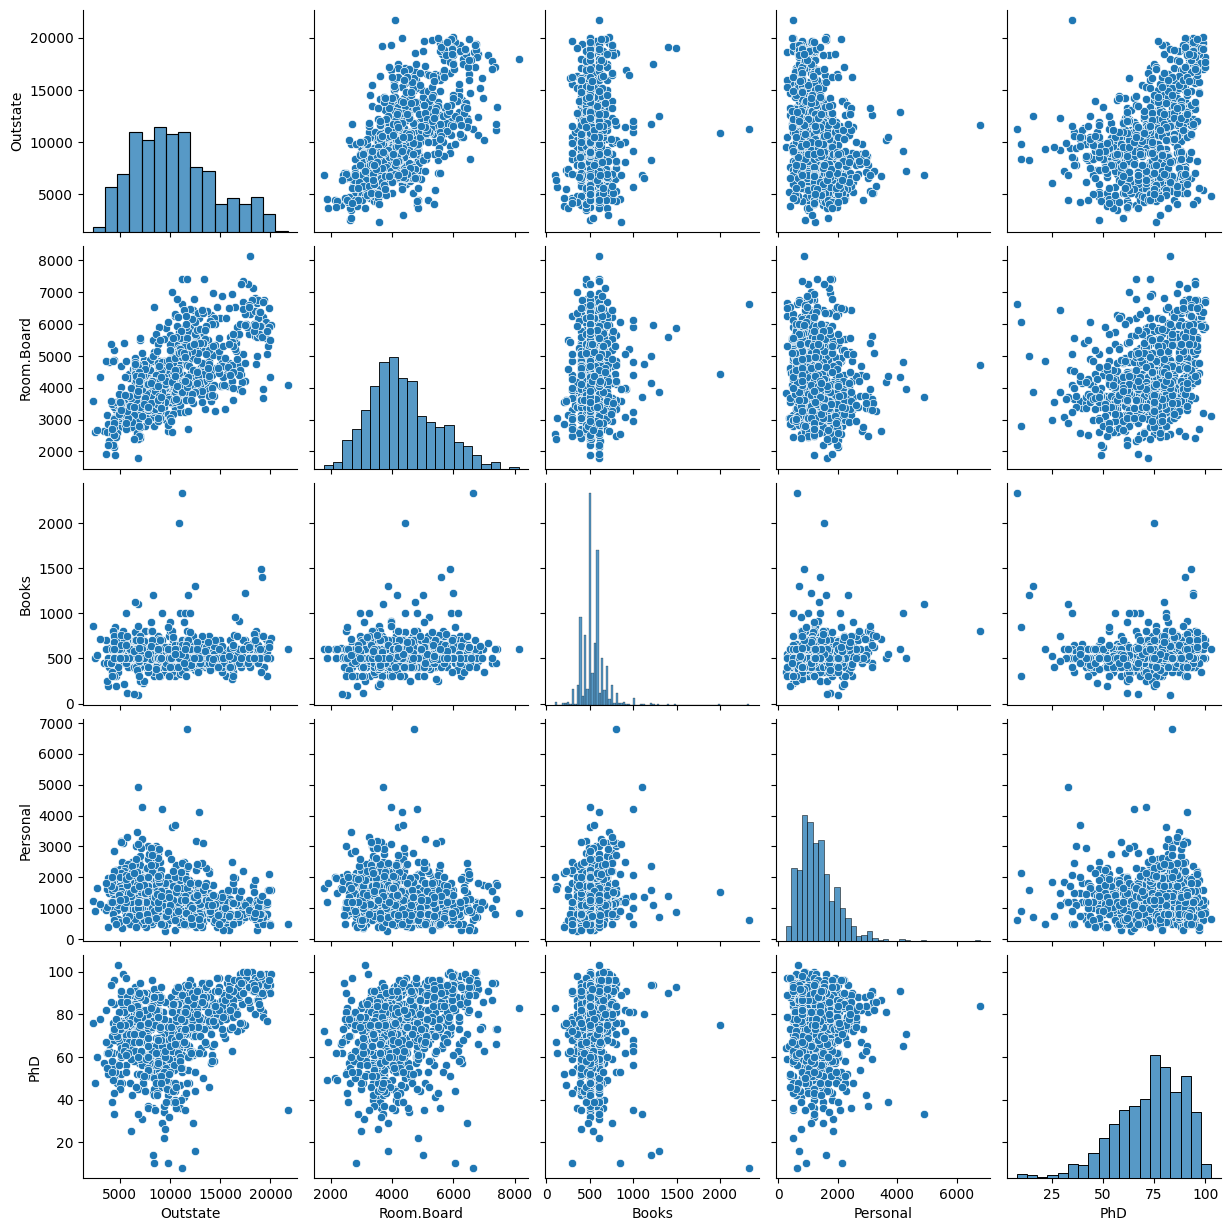

In [55]:
sns.pairplot(college[['Outstate','Room.Board','Books','Personal','PhD']])
plt.show()

In [56]:
college['Elite'] = np.where(college['Top10perc'] > 50, 'Yes', 'No')

college['Elite'].value_counts()

,count
Elite,
No,699
Yes,78


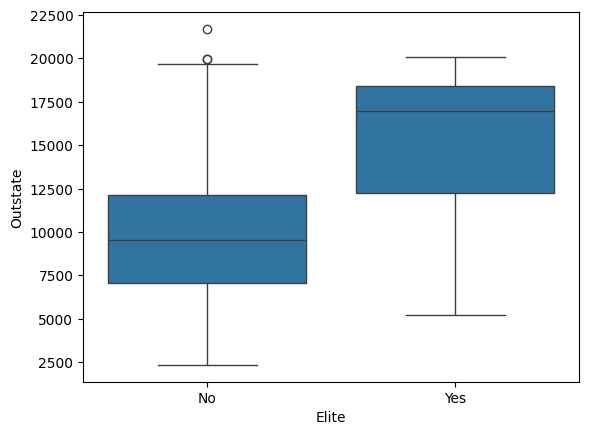

In [57]:
sns.boxplot(x="Elite", y="Outstate", data=college)
plt.show()

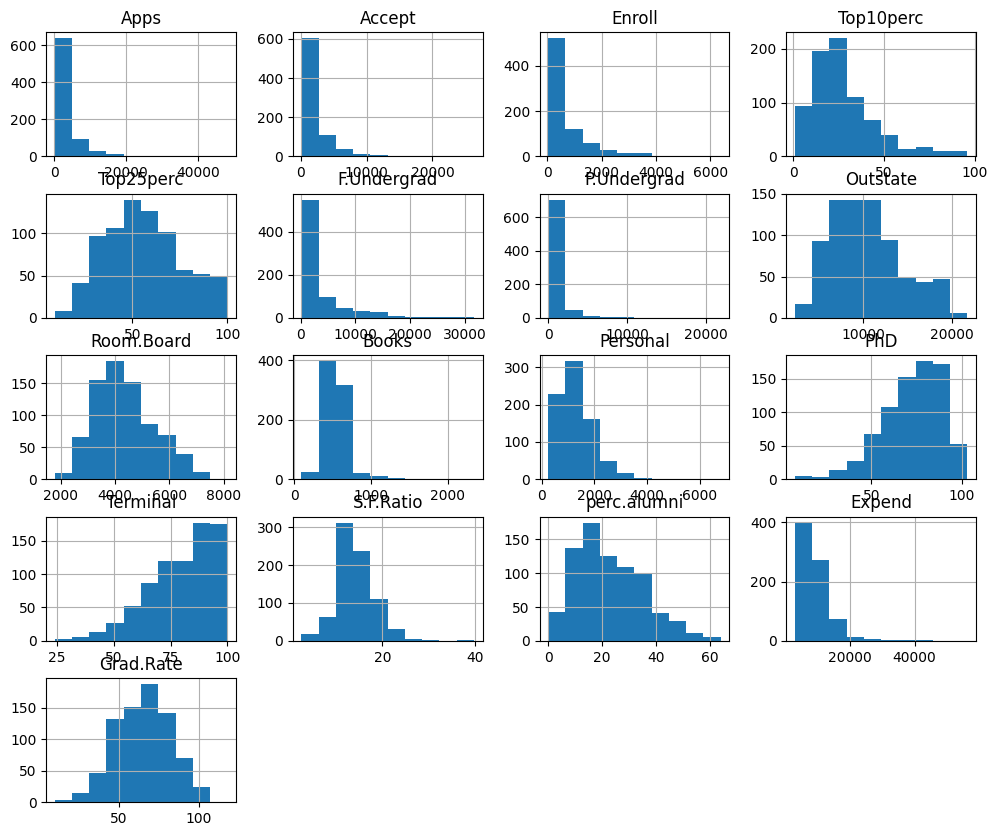

In [58]:
college.hist(figsize=(12,10))
plt.show()

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [75]:
X = train.drop(["Rings", "id"], axis=1)
y = train["Rings"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [76]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_val)

mse_poly = mean_squared_error(y_val, y_pred_poly)
r2_poly = r2_score(y_val, y_pred_poly)

print("Polynomial Regression MSE:", mse_poly)
print("Polynomial Regression R2:", r2_poly)

Polynomial Regression MSE: 3.773074806140121
Polynomial Regression R2: 0.6326962558052436


In [77]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

mse_rf = mean_squared_error(y_val, y_pred_rf)
r2_rf = r2_score(y_val, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 3.592980071977291
Random Forest R2: 0.6502282353091002


In [78]:
results = pd.DataFrame({
    "Model": ["Polynomial Regression", "Random Forest"],
    "R2": [r2_poly, r2_rf],
    "MSE": [mse_poly, mse_rf]
})

results

,Model,R2,MSE
0,Polynomial Regression,0.632696,3.773075
1,Random Forest,0.650228,3.592980


In [80]:
rf_model.fit(X, y)

X_test_fixed = X_test.drop(columns=["id"])

predictions_final = rf_model.predict(X_test_fixed)

In [84]:
poly_model.fit(X, y)

X_kaggle = test.drop(columns=["id"])

predictions_final = poly_model.predict(X_kaggle)

In [85]:
submission_final = pd.DataFrame({
    "id": test["id"],
    "Rings": predictions_final
})

submission_final.to_csv("submission_final.csv", index=False)
submission_final.head()

,id,Rings
0,90615,9.262674
1,90616,9.733078
2,90617,10.468224
3,90618,10.132301
4,90619,7.657147
